In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

from tdc.single_pred import HTS, ADME
from rdkit import Chem
from rdkit.Chem import AllChem, Descriptors
from rdkit import DataStructs

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold, KFold
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    roc_auc_score, average_precision_score, balanced_accuracy_score,
    mean_absolute_error, r2_score
)
import torch
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv, global_mean_pool
import torch.nn.functional as F
from torch_geometric.loader import DataLoader
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

## Task & Description 
HIV
Dataset Description: The HIV dataset was introduced by the Drug Therapeutics Program (DTP) AIDS Antiviral Screen, which tested the ability to inhibit HIV replication for over 40,000 compounds. From MoleculeNet.

Task Description: Binary classification. Given a drug SMILES string, predict its activity against HIV virus.

Dataset Statistics: 41,127 drugs.

Dataset Split: Random Split Scaffold Split
- from https://tdcommons.ai/single_pred_tasks/hts/?utm_source#hiv:~:text=BY%204.0.-,HIV,benchmark%20for%20molecular%20machine%20learning.%E2%80%9D%20Chemical%20science%209.2%20(2018)%3A%20513%2D530.,-Dataset%20License%3A 

Caco-2 (Cell Effective Permeability), Wang et al.
Dataset Description: The human colon epithelial cancer cell line, Caco-2, is used as an in vitro model to simulate the human intestinal tissue. The experimental result on the rate of drug passing through the Caco-2 cells can approximate the rate at which the drug permeates through the human intestinal tissue.

Task Description: Regression. Given a drug SMILES string, predict the Caco-2 cell effective permeability.

Dataset Statistics: 906 drugs.

Dataset Split: Random Split Scaffold Split
- from https://tdcommons.ai/single_pred_tasks/adme/#caco-2-cell-effective-permeability-wang-et-al:~:text=site%20of%20action.-,Caco%2D2%20(Cell%20Effective%20Permeability)%2C%20Wang%20et%20al.,Journal%20of%20Chemical%20Information%20and%20Modeling%202016%2056%20(4)%2C%20763%2D773,-Dataset%20License%3A

In [2]:
# Download the data for classification (HTS) and regression (ADME)
HIV_data = HTS(name = 'HIV') #https://tdcommons.ai/single_pred_tasks/hts/?utm_source#hiv:~:text=BY%204.0.-,HIV,benchmark%20for%20molecular%20machine%20learning.%E2%80%9D%20Chemical%20science%209.2%20(2018)%3A%20513%2D530.,-Dataset%20License%3A 

caco2_data = ADME(name = 'Caco2_Wang') #https://tdcommons.ai/single_pred_tasks/adme/#caco-2-cell-effective-permeability-wang-et-al:~:text=site%20of%20action.-,Caco%2D2%20(Cell%20Effective%20Permeability)%2C%20Wang%20et%20al.,Journal%20of%20Chemical%20Information%20and%20Modeling%202016%2056%20(4)%2C%20763%2D773,-Dataset%20License%3A


HIV_df = HIV_data.get_data()
caco2_df = caco2_data.get_data()

print(f"Shape of HIV data: {HIV_df.shape}")
print(f"Shape of caco2 dataframe: {caco2_df.shape}")

display(HIV_df.head())
display(caco2_df.head())
# Y in HIV (classification is a regression label: )

Found local copy...
Loading...
Done!
Found local copy...
Loading...
Done!


Shape of HIV data: (41127, 3)
Shape of caco2 dataframe: (910, 3)


,Drug_ID,Drug,Y
0,Drug 0,CCC1=[O+][Cu-3]2([O+]=C(CC)C1)[O+]=C(CC)CC(CC)...,0
1,Drug 1,C(=Cc1ccccc1)C1=[O+][Cu-3]2([O+]=C(C=Cc3ccccc3...,0
2,Drug 2,CC(=O)N1c2ccccc2Sc2c1ccc1ccccc21,0
3,Drug 3,Nc1ccc(C=Cc2ccc(N)cc2S(=O)(=O)O)c(S(=O)(=O)O)c1,0
4,Drug 4,O=S(=O)(O)CCS(=O)(=O)O,0


,Drug_ID,Drug,Y
0,(-)-epicatechin,Oc1cc(O)c2c(c1)OC(c1ccc(O)c(O)c1)C(O)C2,-6.220000
1,"(2E,4Z,8Z)-N-isobutyldodeca-2,4,10-triene-8 -y...",C/C=C\C#CCC/C=C\C=C\C(=O)NCC(C)C,-3.860000
2,codeine,COc1ccc2c3c1O[C@H]1[C@@H](O)C=C[C@H]4[C@@H](C2...,-4.090000
3,creatinine,CN1CC(=O)NC1=N,-5.935409
4,danazol,C#C[C@]1(O)CC[C@H]2[C@@H]3CCC4=Cc5oncc5C[C@]4(...,-4.840000


In [3]:
def basic_table_checks(df, name):
    print(f"\n------ {name} -----")
    print("Columns:", list(df.columns))
    print("\nDtypes:")
    print(df.dtypes)
    print("\nMissing values per column:")
    print(df.isna().sum()) # check NaNs
    print("\nNumber of duplicate rows:", df.duplicated().sum())

    if "Drug" in df.columns:
        print("Number of duplicate SMILES in Drug column:", df["Drug"].duplicated().sum())
    elif "SMILES" in df.columns:
        print("Number of duplicate SMILES in SMILES column:", df["SMILES"].duplicated().sum())

basic_table_checks(HIV_df, "HIV")
basic_table_checks(caco2_df, "Caco2_Wang")


------ HIV -----
Columns: ['Drug_ID', 'Drug', 'Y']

Dtypes:
Drug_ID    object
Drug       object
Y           int64
dtype: object

Missing values per column:
Drug_ID    0
Drug       0
Y          0
dtype: int64

Number of duplicate rows: 0
Number of duplicate SMILES in Drug column: 0

------ Caco2_Wang -----
Columns: ['Drug_ID', 'Drug', 'Y']

Dtypes:
Drug_ID     object
Drug        object
Y          float64
dtype: object

Missing values per column:
Drug_ID    0
Drug       0
Y          0
dtype: int64

Number of duplicate rows: 0
Number of duplicate SMILES in Drug column: 4


In [4]:
# Identify the files and label the columsn
def infer_columns(df):
    smiles_col = None
    label_col = None

    for c in df.columns:
        if c.lower() in ["drug", "smiles", "molecule"]:
            smiles_col = c
        if c.lower() in ["y", "label", "target"]:
            label_col = c

    return smiles_col, label_col

hiv_smiles_col, hiv_label_col = infer_columns(HIV_df)
caco2_smiles_col, caco2_label_col = infer_columns(caco2_df)

print("HIV:", hiv_smiles_col, hiv_label_col)
print("Caco2:", caco2_smiles_col, caco2_label_col)

HIV: Drug Y
Caco2: Drug Y


In [5]:
# Check SMILES with RDKit
def parse_smiles(smiles):
    if pd.isna(smiles):
        return None
    try:
        return Chem.MolFromSmiles(smiles)
    except Exception:
        return None

hiv_mols = HIV_df[hiv_smiles_col].apply(parse_smiles)
caco2_mols = caco2_df[caco2_smiles_col].apply(parse_smiles)

print("Valid HIV molecules:", hiv_mols.notna().sum(), "/", len(hiv_mols))
print("Valid Caco2 molecules:", caco2_mols.notna().sum(), "/", len(caco2_mols))

hiv_invalid = HIV_df.loc[hiv_mols.isna(), [hiv_smiles_col, hiv_label_col]].head()
caco2_invalid = caco2_df.loc[caco2_mols.isna(), [caco2_smiles_col, caco2_label_col]].head()

display(hiv_invalid)
display(caco2_invalid)

[07:20:38] Explicit valence for atom # 3 Al, 6, is greater than permitted
[07:20:38] Explicit valence for atom # 5 B, 5, is greater than permitted
[07:20:40] Explicit valence for atom # 16 Al, 9, is greater than permitted
[07:20:41] Explicit valence for atom # 4 Al, 9, is greater than permitted
[07:20:43] Explicit valence for atom # 12 Al, 7, is greater than permitted
[07:20:43] Explicit valence for atom # 13 Al, 7, is greater than permitted
[07:20:44] WARNING: not removing hydrogen atom without neighbors
[07:20:44] WARNING: not removing hydrogen atom without neighbors
[07:20:44] Explicit valence for atom # 8 Ge, 5, is greater than permitted


Valid HIV molecules: 41120 / 41127
Valid Caco2 molecules: 910 / 910


,Drug,Y
137,O=C1O[Al]23(OC1=O)(OC(=O)C(=O)O2)OC(=O)C(=O)O3,0
987,Cc1ccc([B-2]2(c3ccc(C)cc3)=NCCO2)cc1,0
12882,Oc1ccc(C2Oc3cc(O)cc4c3C(=[O+][AlH3-3]35([O+]=C...,0
18293,CC1=C2[OH+][AlH3-3]34([O+]=C2C=CN1C)([O+]=C1C=...,0
30784,CC(c1cccs1)=[N+]1[N-]C(N)=[S+][AlH3-]12[OH+]B(...,0


,Drug,Y


## Construct Graphs for GNN from SMILES

In [6]:
# SMILES -> Graph
def smiles_to_graph(smiles):
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None

    # Node features (per atom)
    atom_features = []
    for atom in mol.GetAtoms():
        features = [
            atom.GetAtomicNum(), # e.g. 6=Carbon, 7=Nitrogen
            atom.GetDegree(), # number of bonds
            atom.GetFormalCharge(),
            int(atom.GetIsAromatic()),
            int(atom.IsInRing()),
        ]
        atom_features.append(features)

    x = torch.tensor(atom_features, dtype=torch.float)

    # Edge index (bonds, bidirectional)
    edges = []
    for bond in mol.GetBonds():
        i, j = bond.GetBeginAtomIdx(), bond.GetEndAtomIdx()
        edges += [[i, j], [j, i]]  # undirected = both directions

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    return Data(x=x, edge_index=edge_index)

In [11]:
# Build dataset
dataset = []
for smiles, label in zip(HIV_df["Drug"], HIV_df["Y"]):
    g = smiles_to_graph(smiles)
    if g:
        g.y = torch.tensor([label], dtype=torch.float)
        dataset.append(g)

[07:25:49] Explicit valence for atom # 3 Al, 6, is greater than permitted
[07:25:49] Explicit valence for atom # 5 B, 5, is greater than permitted
[07:25:55] Explicit valence for atom # 16 Al, 9, is greater than permitted
[07:25:57] Explicit valence for atom # 4 Al, 9, is greater than permitted
[07:26:12] Explicit valence for atom # 12 Al, 7, is greater than permitted
[07:26:12] Explicit valence for atom # 13 Al, 7, is greater than permitted
[07:26:18] WARNING: not removing hydrogen atom without neighbors
[07:26:18] WARNING: not removing hydrogen atom without neighbors
[07:26:19] Explicit valence for atom # 8 Ge, 5, is greater than permitted


In [12]:
from collections import Counter

print(f"Total molecules: {len(dataset)}")
print(f"Class distribution: {Counter([int(g.y.item()) for g in dataset])}")
print(f"Avg nodes (atoms): {sum(g.num_nodes for g in dataset) / len(dataset):.1f}")
print(f"Avg edges (bonds): {sum(g.num_edges for g in dataset) / len(dataset):.1f}")
print(f"Node feature dim: {dataset[0].x.shape[1]}")

# Per-graph summary
for i, g in enumerate(dataset[:5]):
    print(f"Drug {i}: {g.num_nodes} atoms, {g.num_edges//2} bonds, label={int(g.y.item())}")

Total molecules: 41120
Class distribution: Counter({0: 39677, 1: 1443})
Avg nodes (atoms): 25.5
Avg edges (bonds): 54.9
Node feature dim: 5
Drug 0: 19 atoms, 20 bonds, label=0
Drug 1: 39 atoms, 44 bonds, label=0
Drug 2: 21 atoms, 24 bonds, label=0
Drug 3: 24 atoms, 25 bonds, label=0
Drug 4: 10 atoms, 9 bonds, label=0


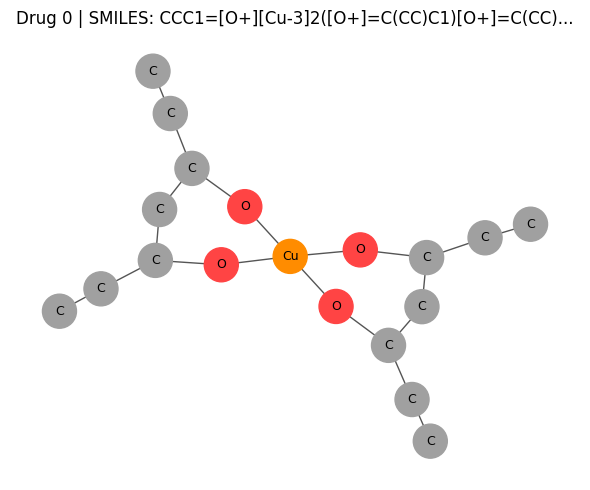

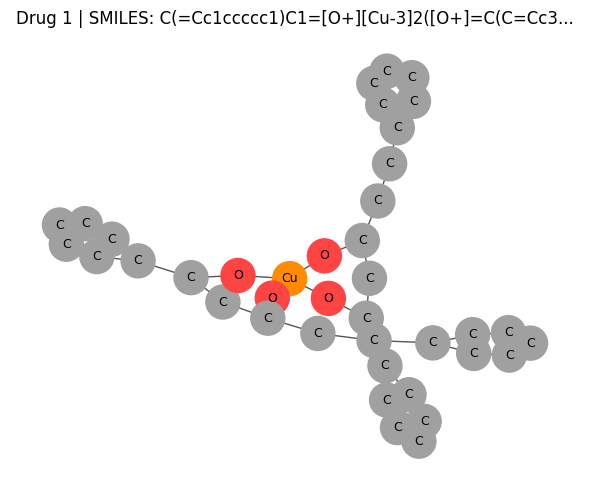

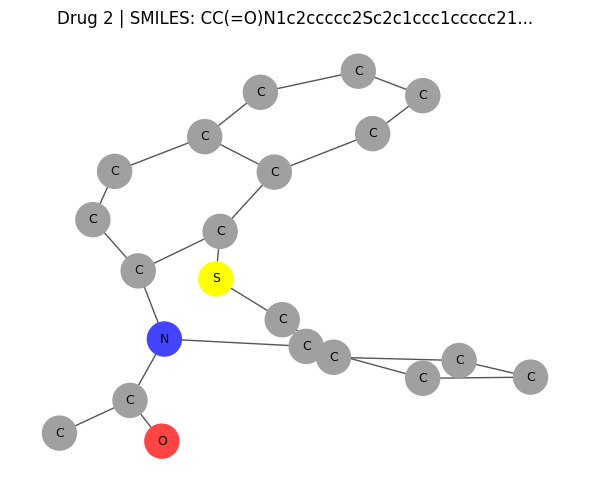

In [17]:
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.utils import to_networkx

def visualize_molecule(pyg_graph, smiles, idx=0):
    G = to_networkx(pyg_graph, to_undirected=True)
    
    # Use atomic numbers from node features to label nodes
    atomic_nums = pyg_graph.x[:, 0].int().tolist()
    atom_map = {1:"H", 6:"C", 7:"N", 8:"O", 16:"S", 17:"Cl", 9:"F", 35:"Br", 29:"Cu"}
    labels = {i: atom_map.get(a, str(a)) for i, a in enumerate(atomic_nums)}
    
    # Color by atom type
    color_map = {"C":"#a0a0a0", "N":"#4444ff", "O":"#ff4444", 
                 "S":"#ffff00", "Cl":"#00ff00", "F":"#00ffff", "Cu": "#ff8c00"}
    colors = [color_map.get(labels[i], "#ffffff") for i in range(len(labels))]
    
    plt.figure(figsize=(6, 5))
    plt.title(f"Drug {idx} | SMILES: {smiles[:40]}...")
    nx.draw(G, labels=labels, node_color=colors, 
            node_size=600, font_size=9, edge_color="#555")
    plt.tight_layout()
    plt.show()

# Visualize first 3 molecules
for i in range(3):
    visualize_molecule(dataset[i], HIV_df["Drug"].iloc[i], idx=i)

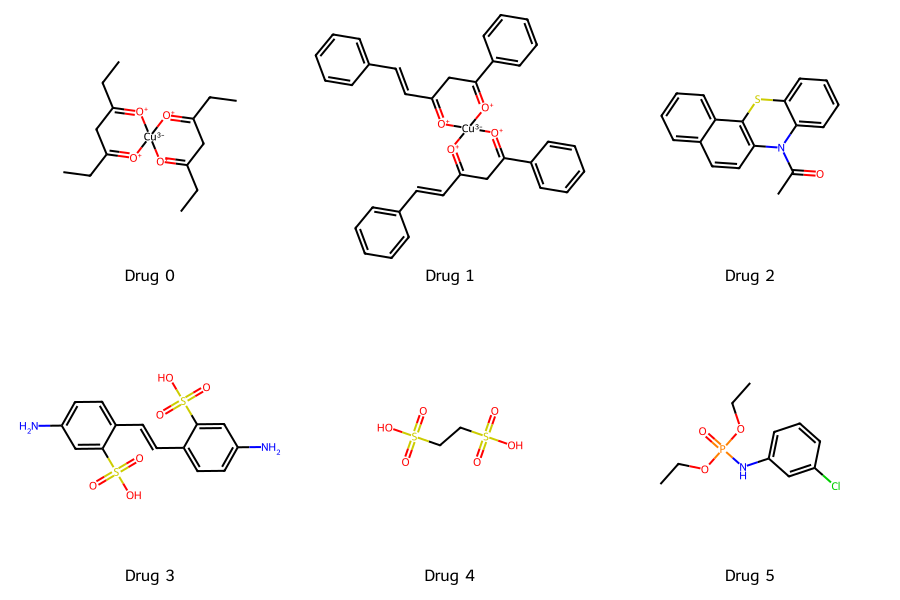

In [18]:
from rdkit import Chem
from rdkit.Chem import Draw
from IPython.display import display

mols = [Chem.MolFromSmiles(s) for s in HIV_df["Drug"].iloc[:6]]
img = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(300, 300),
                           legends=[f"Drug {i}" for i in range(6)])
display(img)  # in Jupyter
# img.save("molecules.png")  # or save to file

## Train GNN on Binary Classification Task for HIV

In [ ]:
class MoleculeGNN(torch.nn.Module):
    def __init__(self, in_channels=5, hidden=64):
        super().__init__()
        self.conv1 = GCNConv(in_channels, hidden) #GNN convolutiontal layer
        self.conv2 = GCNConv(hidden, hidden)
        self.classifier = torch.nn.Linear(hidden, 1)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        x = F.relu(self.conv1(x, edge_index))
        x = F.relu(self.conv2(x, edge_index))
        x = global_mean_pool(x, batch)   # graph-level embedding
        return self.classifier(x).squeeze()

Epoch 1: Loss = 0.1505
Epoch 2: Loss = 0.1451
Epoch 3: Loss = 0.1442


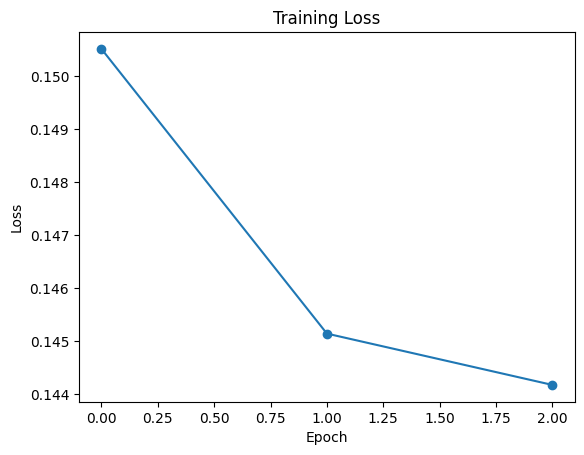

In [22]:
# Train/test split
split = int(0.8 * len(dataset))
train_data, test_data = dataset[:split], dataset[split:]
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)

# Train GNN
model = MoleculeGNN()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = torch.nn.BCEWithLogitsLoss()

train_losses = []
epochs = 3
for epoch in range(epochs):
    model.train()
    total_loss = 0
    for batch in train_loader:
        optimizer.zero_grad()
        out = model(batch)
        loss = criterion(out, batch.y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: Loss = {avg_loss:.4f}")

# Plot
plt.plot(train_losses, marker='o')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.show()

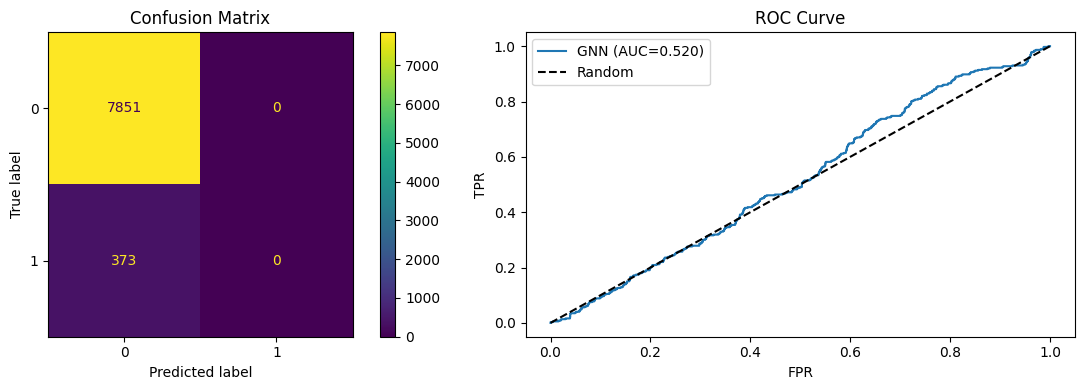

In [23]:
from sklearn.metrics import confusion_matrix, roc_auc_score, roc_curve, ConfusionMatrixDisplay
test_loader = DataLoader(test_data, batch_size=32, shuffle=True)
model.eval()
all_preds, all_probs, all_labels = [], [], []

with torch.no_grad():
    for batch in test_loader:
        logits = model(batch)
        probs = torch.sigmoid(logits).cpu().numpy()
        preds = (probs > 0.5).astype(int)
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(batch.y.cpu().numpy())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
ConfusionMatrixDisplay(cm).plot(ax=axes[0])
axes[0].set_title("Confusion Matrix")

# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
auc = roc_auc_score(all_labels, all_probs)
axes[1].plot(fpr, tpr, label=f"GNN (AUC={auc:.3f})")
axes[1].plot([0,1],[0,1], 'k--', label="Random")
axes[1].set_xlabel("FPR"), axes[1].set_ylabel("TPR")
axes[1].set_title("ROC Curve")
axes[1].legend()

plt.tight_layout()
plt.show()